In [71]:
import pandas as pd
import numpy as np
import json

In [72]:
aircrafts = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/aircrafts_data.csv')
airports = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/airports_data.csv')
boarding = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/boarding_passes.csv')
bookings = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/bookings.csv')
flights = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/flights.csv')
seats = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/seats.csv')
ticket_flights = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/ticket_flights.csv')
tickets = pd.read_csv('/Users/vijaypatil/Desktop/Innomatics/EDA/20375187-Airline_Datasets/tickets.csv')


print("aircrafts:", aircrafts.shape)
print("airports:", airports.shape)
print("boarding:", boarding.shape)
print("bookings:", bookings.shape)
print("flights:", flights.shape)
print("seats:", seats.shape)
print("ticket_flights:", ticket_flights.shape)
print("tickets:", tickets.shape)

aircrafts: (9, 3)
airports: (104, 5)
boarding: (579686, 4)
bookings: (262788, 3)
flights: (33121, 10)
seats: (1339, 3)
ticket_flights: (1045726, 4)
tickets: (366733, 3)


In [73]:
aircrafts.columns

Index(['aircraft_code', 'model', 'range'], dtype='str')

In [74]:
aircrafts.head()

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600


In [75]:
seats.columns

Index(['aircraft_code', 'seat_no', 'fare_conditions'], dtype='str')

In [76]:
seats.head()

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business


In [77]:
aircrafts.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   aircraft_code  9 non-null      str  
 1   model          9 non-null      str  
 2   range          9 non-null      int64
dtypes: int64(1), str(2)
memory usage: 348.0 bytes


In [78]:
airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   airport_code  104 non-null    str  
 1   airport_name  104 non-null    str  
 2   city          104 non-null    str  
 3   coordinates   104 non-null    str  
 4   timezone      104 non-null    str  
dtypes: str(5)
memory usage: 4.2 KB


In [79]:
boarding.info()

<class 'pandas.DataFrame'>
RangeIndex: 579686 entries, 0 to 579685
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ticket_no    579686 non-null  int64
 1   flight_id    579686 non-null  int64
 2   boarding_no  579686 non-null  int64
 3   seat_no      579686 non-null  str  
dtypes: int64(3), str(1)
memory usage: 17.7 MB


In [80]:
bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 262788 entries, 0 to 262787
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   book_ref      262788 non-null  str  
 1   book_date     262788 non-null  str  
 2   total_amount  262788 non-null  int64
dtypes: int64(1), str(2)
memory usage: 6.0 MB


In [81]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 33121 entries, 0 to 33120
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   flight_id            33121 non-null  int64
 1   flight_no            33121 non-null  str  
 2   scheduled_departure  33121 non-null  str  
 3   scheduled_arrival    33121 non-null  str  
 4   departure_airport    33121 non-null  str  
 5   arrival_airport      33121 non-null  str  
 6   status               33121 non-null  str  
 7   aircraft_code        33121 non-null  str  
 8   actual_departure     33121 non-null  str  
 9   actual_arrival       33121 non-null  str  
dtypes: int64(1), str(9)
memory usage: 2.5 MB


In [82]:
seats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   aircraft_code    1339 non-null   str  
 1   seat_no          1339 non-null   str  
 2   fare_conditions  1339 non-null   str  
dtypes: str(3)
memory usage: 31.5 KB


In [83]:
flights.head() # \n --> Missing data present

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N


In [84]:
aircrafts.head()
# 

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600


In [85]:
seats.head() # Mearge based on aircraft codes

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business


In [86]:
ticket_flights.head()

,ticket_no,flight_id,fare_conditions,amount
0,5432159776,30625,Business,42100
1,5435212351,30625,Business,42100
2,5435212386,30625,Business,42100
3,5435212381,30625,Business,42100
4,5432211370,30625,Business,42100


## Missing values and data quality

In [87]:
# Replace the placeholder with a real pandas missing value
aircrafts = aircrafts.replace(r"\N", pd.NA)
airports = airports.replace(r"\N", pd.NA)
boarding = boarding.replace(r"\N", pd.NA)
bookings = bookings.replace(r"\N", pd.NA)
flights = flights.replace(r"\N", pd.NA)
seats = seats.replace(r"\N", pd.NA)
ticket_flights = ticket_flights.replace(r"\N", pd.NA)
tickets = tickets.replace(r"\N", pd.NA)

In [88]:
flights.isnull().sum()

flight_id                  0
flight_no                  0
scheduled_departure        0
scheduled_arrival          0
departure_airport          0
arrival_airport            0
status                     0
aircraft_code              0
actual_departure       16348
actual_arrival         16406
dtype: int64

In [89]:
flights.head()

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,NaN,NaN
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,NaN,NaN
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,NaN,NaN
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,NaN,NaN
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,NaN,NaN


In [90]:
# check duplicated data
print("Duplicate flight IDs:", flights["flight_id"].duplicated().sum())
print("Duplicate ticket numbers:", tickets["ticket_no"].duplicated().sum())
print("Duplicate seat rows:", seats.duplicated(["aircraft_code", "seat_no"]).sum())

Duplicate flight IDs: 0
Duplicate ticket numbers: 0
Duplicate seat rows: 0


In [91]:
# Converting date time format
flights["scheduled_departure"] = pd.to_datetime(flights["scheduled_departure"], errors="coerce")
flights["scheduled_arrival"] = pd.to_datetime(flights["scheduled_arrival"], errors="coerce")
flights["actual_departure"] = pd.to_datetime(flights["actual_departure"], errors="coerce")
flights["actual_arrival"] = pd.to_datetime(flights["actual_arrival"], errors="coerce")

bookings["book_date"] = pd.to_datetime(bookings["book_date"], errors="coerce")

In [92]:
# Clean the JSON like Text columns

#Inference: The JSON-like text column contained aircraft information in multiple languages. The English (en) value was extracted and retained, making the data easier to read, analyze, and use for further processing. This also reduced unnecessary language-specific information from the dataset.

aircrafts['model'] = aircrafts['model'].apply(
    lambda x: json.loads(x)['en'] if pd.notna(x) else np.nan
)


In [93]:
aircrafts

,aircraft_code,model,range
0,773,Boeing 777-300,11100
1,763,Boeing 767-300,7900
2,SU9,Sukhoi Superjet-100,3000
3,320,Airbus A320-200,5700
4,321,Airbus A321-200,5600
5,319,Airbus A319-100,6700
6,733,Boeing 737-300,4200
7,CN1,Cessna 208 Caravan,1200
8,CR2,Bombardier CRJ-200,2700


In [94]:
import json
import pandas as pd
import numpy as np

def get_english_name(value):
    if pd.isna(value):
        return np.nan

    try:
        return json.loads(value)["en"]
    except (json.JSONDecodeError, TypeError, KeyError):
        return np.nan



In [95]:
def get_english_name(value):
    if pd.isna(value):
        return value
    return json.loads(value)["en"]


airports["airport_name"] = airports["airport_name"].apply(get_english_name)
airports["city"] = airports["city"].apply(get_english_name)

aircrafts.head()

,aircraft_code,model,range
0,773,Boeing 777-300,11100
1,763,Boeing 767-300,7900
2,SU9,Sukhoi Superjet-100,3000
3,320,Airbus A320-200,5700
4,321,Airbus A321-200,5600


In [96]:
# Save the cleaned CSV files
aircrafts.to_csv("aircrafts_clean.csv", index=False)
airports.to_csv("airports_clean.csv", index=False)
boarding.to_csv("boarding_clean.csv", index=False)
bookings.to_csv("bookings_clean.csv", index=False)
flights.to_csv("flights_clean.csv", index=False)
seats.to_csv("seats_clean.csv", index=False)
ticket_flights.to_csv("ticket_flights_clean.csv", index=False)
tickets.to_csv("tickets_clean.csv", index=False)

print("Cleaned CSV files saved.")

Cleaned CSV files saved.


In [97]:
# One time preparation for flight level analysis
# 1) Nu of seats for each aircraft type
print(seats.groupby('aircraft_code')['fare_conditions'].value_counts())

aircraft_code  fare_conditions
319            Economy             96
               Business            20
320            Economy            120
               Business            20
321            Economy            142
               Business            28
733            Economy            118
               Business            12
763            Economy            192
               Business            30
773            Economy            324
               Comfort             48
               Business            30
CN1            Economy             12
CR2            Economy             50
SU9            Economy             85
               Business            12
Name: count, dtype: int64


In [98]:
seats.groupby('aircraft_code').size().reset_index(name='Size')

,aircraft_code,Size
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402
6,CN1,12
7,CR2,50
8,SU9,97


In [99]:
# 2) Nu of boarded passengers for each flight

# Inference: The number of boarded passengers varies across flights, indicating that different flights have different passenger loads.
boarding['flight_id'].value_counts()

flight_id
9819     374
305      365
249      365
250      361
301      357
        ... 
24768      1
1304       1
8911       1
19218      1
13020      1
Name: count, Length: 11518, dtype: int64

In [100]:
# 3) tickit revenue for each flight

# Inference: Ticket revenue differs across flights because the number of tickets sold and ticket prices vary between flights.

# Type 1 groupby

ticket_flights.groupby('flight_id')['amount'].sum()

flight_id
1        693700
2        867700
3        853600
5        800800
6        868300
          ...  
33117     87400
33118     86900
33119     21600
33120     70200
33121     98700
Name: amount, Length: 22226, dtype: int64

In [101]:
revenue=ticket_flights.groupby(['flight_id', 'fare_conditions'])['amount'].sum()
print(revenue.head(5))

flight_id  fare_conditions
1          Business           240000
           Economy            453700
2          Business           280000
           Economy            587700
3          Business           300000
Name: amount, dtype: int64


In [102]:
# Type 2 groupby
ticket_flights['Average_fare']=ticket_flights.groupby('flight_id')['amount'].agg('mean')
ticket_flights['Average_fare']

0                  NaN
1          8781.012658
2          8591.089109
3          8800.000000
4                  NaN
              ...     
1045721            NaN
1045722            NaN
1045723            NaN
1045724            NaN
1045725            NaN
Name: Average_fare, Length: 1045726, dtype: float64

In [103]:
revenue_by_flight = (ticket_flights.groupby("flight_id").agg(ticket_count=("ticket_no", "count"),
        ticket_revenue=("amount", "sum")).reset_index())

display(revenue_by_flight.head())

# Average ticket fare for each flight
fare_by_flight = (
    ticket_flights.groupby("flight_id")["amount"]
    .mean()
    .reset_index(name="average_fare")
)

fare_by_flight.head()

,flight_id,ticket_count,ticket_revenue
0,1,79,693700
1,2,101,867700
2,3,97,853600
3,5,93,800800
4,6,101,868300


,flight_id,average_fare
0,1,8781.012658
1,2,8591.089109
2,3,8800.000000
3,5,8610.752688
4,6,8597.029703


In [104]:
flights_aircrafts = flights.merge(
    aircrafts,
    on='aircraft_code',
    how='left'
)
flights_aircrafts
ticket_flights_flights = ticket_flights.merge(
    flights,
    on='flight_id',
    how='left'
)
ticket_flights_flights

,ticket_no,flight_id,fare_conditions,amount,Average_fare,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,5432159776,30625,Business,42100,NaN,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00
1,5435212351,30625,Business,42100,8781.012658,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00
2,5435212386,30625,Business,42100,8591.089109,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00
3,5435212381,30625,Business,42100,8800.000000,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00
4,5432211370,30625,Business,42100,NaN,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045721,5435097522,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT
1045722,5435097521,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT
1045723,5435104384,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT
1045724,5435104352,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT


In [105]:
final_flights_data = ticket_flights_flights.merge(
    flights_aircrafts[["flight_id", "aircraft_code", "model", "range"]],
    on="flight_id",
    how="left",
    suffixes=("", "_aircraft")
)

final_flights_data

,ticket_no,flight_id,fare_conditions,amount,Average_fare,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,aircraft_code_aircraft,model,range
0,5432159776,30625,Business,42100,NaN,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00,773,Boeing 777-300,11100
1,5435212351,30625,Business,42100,8781.012658,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00,773,Boeing 777-300,11100
2,5435212386,30625,Business,42100,8591.089109,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00,773,Boeing 777-300,11100
3,5435212381,30625,Business,42100,8800.000000,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00,773,Boeing 777-300,11100
4,5432211370,30625,Business,42100,NaN,PG0013,2017-07-16 18:15:00+03:00,2017-07-16 20:00:00+03:00,AER,SVO,Arrived,773,2017-07-16 18:18:00+03:00,2017-07-16 20:04:00+03:00,773,Boeing 777-300,11100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045721,5435097522,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT,733,Boeing 737-300,4200
1045722,5435097521,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT,733,Boeing 737-300,4200
1045723,5435104384,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT,733,Boeing 737-300,4200
1045724,5435104352,32094,Economy,5200,NaN,PG0708,2017-09-14 17:15:00+03:00,2017-09-14 18:00:00+03:00,SGC,OVS,Scheduled,733,NaT,NaT,733,Boeing 737-300,4200


In [106]:
# 1. Start with flights
flight_data = flights.copy()


# 2. Add aircraft model and range
flight_data = flight_data.merge(
    aircrafts[['aircraft_code', 'model', 'range']],
    on='aircraft_code',
    how='left'
)


# 3. Calculate aircraft capacity
aircraft_capacity = (
    seats.groupby('aircraft_code')
    .size()
    .reset_index(name='capacity')
)

flight_data = flight_data.merge(
    aircraft_capacity,
    on='aircraft_code',
    how='left'
)


# 4. Calculate boarded passengers for each flight
boarded_by_flight = (
    boarding.groupby('flight_id')
    .size()
    .reset_index(name='boarded_passengers')
)

flight_data = flight_data.merge(
    boarded_by_flight,
    on='flight_id',
    how='left'
)


# 5. Calculate revenue for each flight
revenue_by_flight = (
    ticket_flights.groupby('flight_id')['amount']
    .sum()
    .reset_index(name='revenue')
)

flight_data = flight_data.merge(
    revenue_by_flight,
    on='flight_id',
    how='left'
)


# 6. Calculate fare/revenue by fare condition for each flight
fare_by_flight = (
    ticket_flights.groupby('flight_id')['amount']
    .mean()
    .reset_index(name='average_fare')
)

flight_data = flight_data.merge(
    fare_by_flight,
    on='flight_id',
    how='left'
)


# Check final dataset
flight_data.head()


,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,model,range,capacity,boarded_passengers,revenue,average_fare
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,Airbus A319-100,6700,116,NaN,76600.0,38300.000000
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,546400.0,19514.285714
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,777400.0,18960.975610
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,130800.0,14533.333333
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,Sukhoi Superjet-100,3000,97,NaN,150100.0,10006.666667


In [107]:
flight_data

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,model,range,capacity,boarded_passengers,revenue,average_fare
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,Airbus A319-100,6700,116,NaN,76600.0,38300.000000
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,546400.0,19514.285714
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,777400.0,18960.975610
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,130800.0,14533.333333
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,Sukhoi Superjet-100,3000,97,NaN,150100.0,10006.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,Bombardier CRJ-200,2700,50,16.0,87400.0,5462.500000
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00,Bombardier CRJ-200,2700,50,16.0,86900.0,5431.250000
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,21600.0,5400.000000
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00,Bombardier CRJ-200,2700,50,13.0,70200.0,5400.000000


In [108]:
departure_city = airports[["airport_code", "city"]].rename(
    columns={
        "airport_code": "departure_airport",
        "city": "departure_city"
    }
)

arrival_city = airports[["airport_code", "city"]].rename(
    columns={
        "airport_code": "arrival_airport",
        "city": "arrival_city"
    }
)

flight_data = flight_data.merge(departure_city, on="departure_airport", how="left")
flight_data = flight_data.merge(arrival_city, on="arrival_airport", how="left")

flight_data[["flight_id", "departure_city", "arrival_city"]].head()

,flight_id,departure_city,arrival_city
0,1185,Moscow,Bratsk
1,3979,Moscow,Khanty-Mansiysk
2,4739,Moscow,Sochi
3,5502,Moscow,Ufa
4,6938,Moscow,Ulyanovsk


In [109]:
print("Original unique flights:", flights["flight_id"].nunique())
print("Final unique flights:", flight_data["flight_id"].nunique())
print("Final rows:", len(flight_data))

Original unique flights: 33121
Final unique flights: 33121
Final rows: 33121


## Create Business KPI's(Key Performance Indicator)

In [110]:
flight_data

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,model,range,capacity,boarded_passengers,revenue,average_fare,departure_city,arrival_city
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,Airbus A319-100,6700,116,NaN,76600.0,38300.000000,Moscow,Bratsk
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,546400.0,19514.285714,Moscow,Khanty-Mansiysk
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,777400.0,18960.975610,Moscow,Sochi
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,130800.0,14533.333333,Moscow,Ufa
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,Sukhoi Superjet-100,3000,97,NaN,150100.0,10006.666667,Moscow,Ulyanovsk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,Bombardier CRJ-200,2700,50,16.0,87400.0,5462.500000,Saransk,Moscow
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00,Bombardier CRJ-200,2700,50,16.0,86900.0,5431.250000,Saransk,Moscow
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,21600.0,5400.000000,Saransk,Moscow
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00,Bombardier CRJ-200,2700,50,13.0,70200.0,5400.000000,Saransk,Moscow


In [111]:
flight_data = flight_data.rename(columns={
    'capacity': 'total_seats',
    'revenue': 'ticket_revenue'
})

In [112]:
def get_english_name(value):
    if pd.isna(value):
        return value

    if isinstance(value, str) and value.startswith("{"):
        return json.loads(value)["en"]

    return value

In [113]:

flight_data["departure_city"] = flight_data["departure_city"].apply(get_english_name)
flight_data["arrival_city"] = flight_data["arrival_city"].apply(get_english_name)

In [114]:
# Keep the original missing passenger values for the occupancy population.
# A missing boarding record is not automatically treated as zero passengers.

flight_data["empty_seats"] = (
    flight_data["total_seats"] - flight_data["boarded_passengers"]
)

flight_data["occupancy_rate"] = (
    flight_data["boarded_passengers"] / flight_data["total_seats"]
)

flight_data["revenue_per_available_seat"] = (
    flight_data["ticket_revenue"] / flight_data["total_seats"]
)

flight_data["route"] = (
    flight_data["departure_airport"] + " -> " + flight_data["arrival_airport"]
)

flight_data["month"] = flight_data["scheduled_departure"].dt.month
flight_data["day_name"] = flight_data["scheduled_departure"].dt.day_name()
flight_data["departure_hour"] = flight_data["scheduled_departure"].dt.hour

flight_data.head()

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,...,average_fare,departure_city,arrival_city,empty_seats,occupancy_rate,revenue_per_available_seat,route,month,day_name,departure_hour
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,...,38300.000000,Moscow,Bratsk,NaN,NaN,660.344828,DME -> BTK,9,Sunday,9
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,...,19514.285714,Moscow,Khanty-Mansiysk,NaN,NaN,10928.000000,VKO -> HMA,8,Friday,14
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,...,18960.975610,Moscow,Sochi,NaN,NaN,3501.801802,VKO -> AER,9,Tuesday,12
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,...,14533.333333,Moscow,Ufa,NaN,NaN,589.189189,SVO -> UFA,9,Tuesday,9
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,...,10006.666667,Moscow,Ulyanovsk,NaN,NaN,1547.422680,SVO -> ULV,9,Monday,12


## Univariate analysis

In [115]:
(flight_data['status'].value_counts(normalize=True)*100).round(2)

status
Arrived      50.44
Scheduled    46.44
On Time       1.56
Cancelled     1.25
Departed      0.18
Delayed       0.12
Name: proportion, dtype: float64

<Axes: xlabel='status', ylabel='count'>

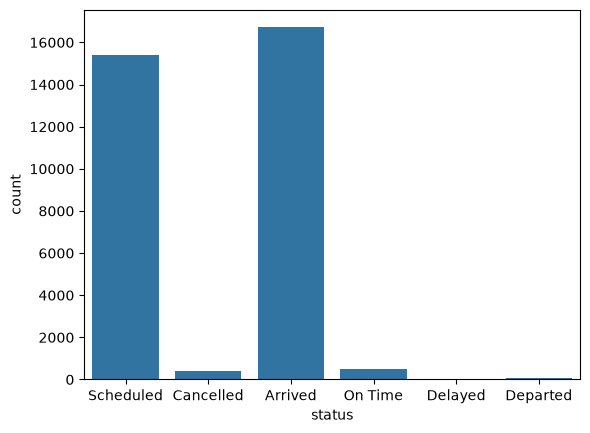

In [116]:
import seaborn as sns
sns.countplot(data=flight_data, x='status')

Inference: The countplot shows the number of flights in each status category, making it easy to compare the distribution of flight statuses.

In [117]:
aircrafts[['aircraft_code','model','range']].sort_values('range',ascending=True)

,aircraft_code,model,range
7,CN1,Cessna 208 Caravan,1200
8,CR2,Bombardier CRJ-200,2700
2,SU9,Sukhoi Superjet-100,3000
6,733,Boeing 737-300,4200
4,321,Airbus A321-200,5600
3,320,Airbus A320-200,5700
5,319,Airbus A319-100,6700
1,763,Boeing 767-300,7900
0,773,Boeing 777-300,11100


<Axes: ylabel='count'>

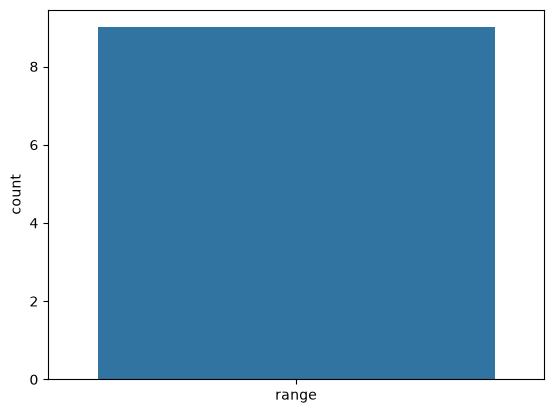

In [118]:
sns.countplot(aircrafts[['aircraft_code','model','range']])

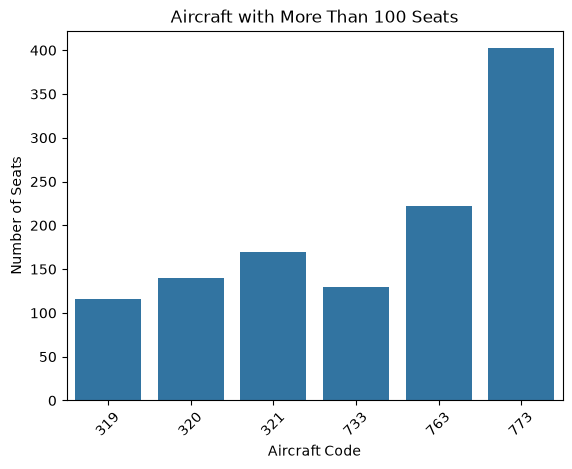

In [119]:
import matplotlib.pyplot as plt
seat_count = seats.groupby('aircraft_code').size()

aircraft_100 = seat_count[seat_count > 100].index

sns.countplot(
    data=seats[seats['aircraft_code'].isin(aircraft_100)],
    x='aircraft_code'
)

plt.xticks(rotation=45)
plt.xlabel("Aircraft Code")
plt.ylabel("Number of Seats")
plt.title("Aircraft with More Than 100 Seats")
plt.show()

Inference: The bar chart shows the aircraft types with more than 100 seats. These aircraft have relatively higher passenger-carrying capacity and can accommodate a larger number of passengers per flight.

In [120]:
seat_count = seats.groupby('aircraft_code').size()

aircraft_100 = seat_count[seat_count > 100].index
aircraft_100 ,seat_count

(Index(['319', '320', '321', '733', '763', '773'], dtype='str', name='aircraft_code'),
 aircraft_code
 319    116
 320    140
 321    170
 733    130
 763    222
 773    402
 CN1     12
 CR2     50
 SU9     97
 dtype: int64)

In [121]:
aircraft_frequency = flights['aircraft_code'].value_counts()

print(aircraft_frequency)

aircraft_code
CN1    9273
CR2    9048
SU9    8504
321    1952
733    1274
319    1239
763    1221
773     610
Name: count, dtype: int64


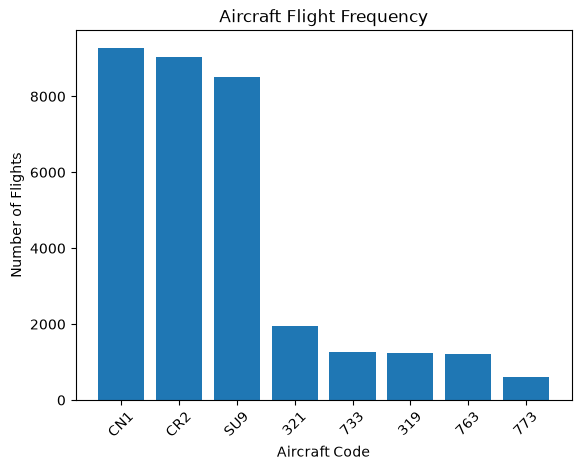

In [122]:
import matplotlib.pyplot as plt

aircraft_frequency = flights['aircraft_code'].value_counts()

plt.bar(aircraft_frequency.index, aircraft_frequency.values)

plt.xlabel("Aircraft Code")
plt.ylabel("Number of Flights")
plt.title("Aircraft Flight Frequency")
plt.xticks(rotation=45)

plt.show()

Inference: The chart shows the flight frequency of each aircraft type. Aircraft with higher frequencies were used for a larger number of scheduled flights during the dataset period.

In [123]:
flight_data['occupancy_rate'] = (
    flight_data['boarded_passengers'] /
    flight_data['total_seats'] * 100
)
flight_data['occupancy_rate']

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
         ... 
33116    32.0
33117    32.0
33118     NaN
33119    26.0
33120     NaN
Name: occupancy_rate, Length: 33121, dtype: float64

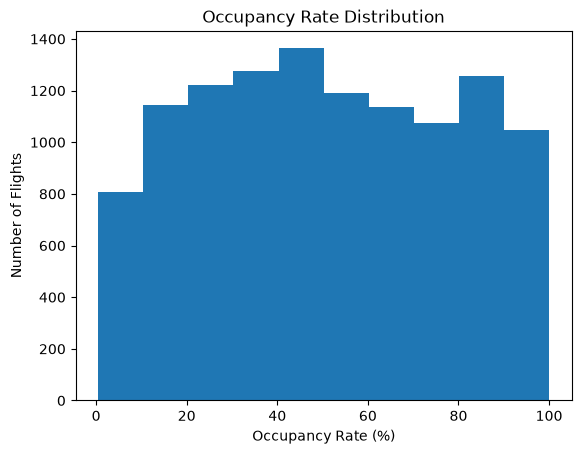

In [124]:
import matplotlib.pyplot as plt

plt.hist(flight_data['occupancy_rate'].dropna(), bins=10)

plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Number of Flights")
plt.title("Occupancy Rate Distribution")

plt.show()

Inference: The histogram shows how flight occupancy rates are distributed. It helps identify whether most flights operate at low, medium, or high occupancy levels and whether there are unusually low or high occupancy flights.

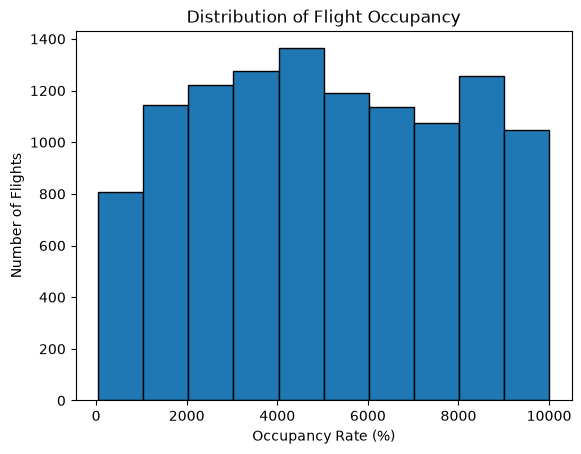

In [125]:
plt.hist(flight_data['occupancy_rate'].dropna() * 100, bins=10, edgecolor='black')

plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Flight Occupancy")

plt.show()

Inference: The histogram shows how flight occupancy rates are distributed across flights and helps identify whether most flights have low, medium, or high occupancy.

In [126]:
ticket_flights['amount'].describe()

count    1.045726e+06
mean     1.985891e+04
std      2.261239e+04
min      3.000000e+03
25%      7.200000e+03
50%      1.340000e+04
75%      2.310000e+04
max      2.033000e+05
Name: amount, dtype: float64

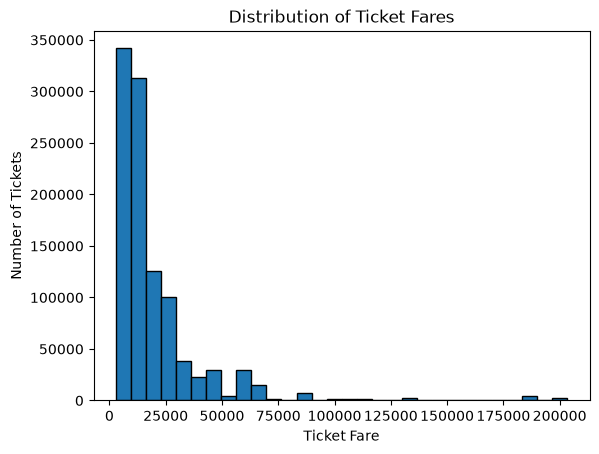

In [127]:
plt.hist(ticket_flights['amount'].dropna(), bins=30, edgecolor='black')

plt.xlabel("Ticket Fare")
plt.ylabel("Number of Tickets")
plt.title("Distribution of Ticket Fares")

plt.show()

<Axes: xlabel='amount', ylabel='Count'>

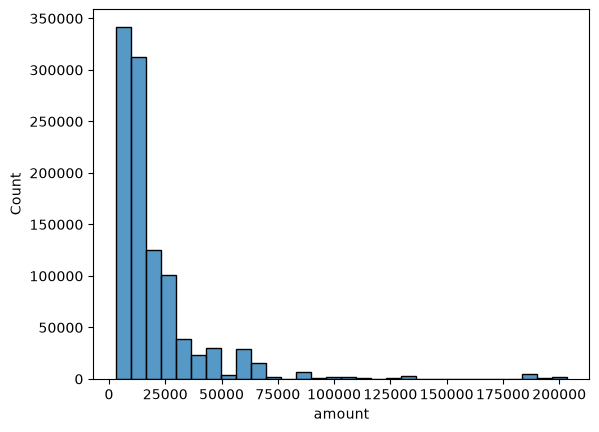

In [128]:
sns.histplot(ticket_flights["amount"], bins=30)

Inference: The distribution shows how ticket fares vary and whether most tickets are concentrated around a particular price range.

## Flight Status Analysis

In [129]:
flight_data['status'].value_counts()

status
Arrived      16707
Scheduled    15383
On Time        518
Cancelled      414
Departed        58
Delayed         41
Name: count, dtype: int64

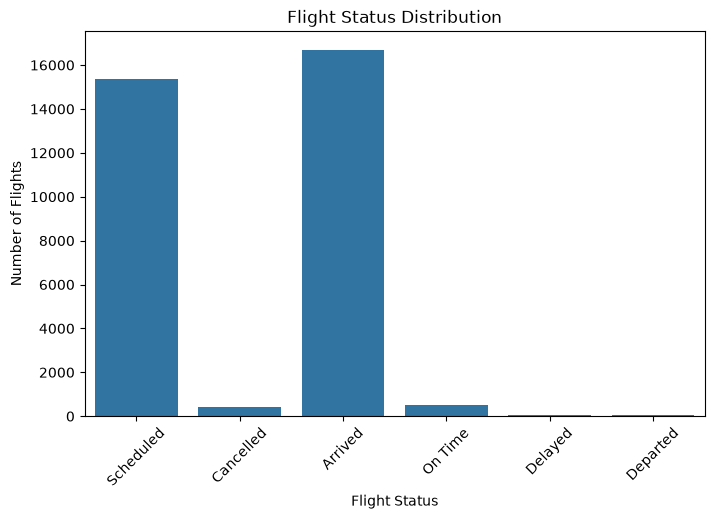

In [130]:
plt.figure(figsize=(8,5))
sns.countplot(data=flight_data, x='status')

plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.title("Flight Status Distribution")
plt.xticks(rotation=45)
plt.show()

## Aircraft data analysis
- Most frequently used aircraft

In [131]:
flight_data

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,...,average_fare,departure_city,arrival_city,empty_seats,occupancy_rate,revenue_per_available_seat,route,month,day_name,departure_hour
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,...,38300.000000,Moscow,Bratsk,NaN,NaN,660.344828,DME -> BTK,9,Sunday,9
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,...,19514.285714,Moscow,Khanty-Mansiysk,NaN,NaN,10928.000000,VKO -> HMA,8,Friday,14
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,...,18960.975610,Moscow,Sochi,NaN,NaN,3501.801802,VKO -> AER,9,Tuesday,12
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,...,14533.333333,Moscow,Ufa,NaN,NaN,589.189189,SVO -> UFA,9,Tuesday,9
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,...,10006.666667,Moscow,Ulyanovsk,NaN,NaN,1547.422680,SVO -> ULV,9,Monday,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,...,5462.500000,Saransk,Moscow,34.0,32.0,1748.000000,SKX -> SVO,8,Wednesday,19
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00,...,5431.250000,Saransk,Moscow,34.0,32.0,1738.000000,SKX -> SVO,7,Friday,19
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT,...,5400.000000,Saransk,Moscow,NaN,NaN,432.000000,SKX -> SVO,9,Friday,19
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00,...,5400.000000,Saransk,Moscow,37.0,26.0,1404.000000,SKX -> SVO,8,Tuesday,19


In [132]:
aircraft_frequency = flight_data['model'].value_counts()

aircraft_frequency.head(10)

model
Cessna 208 Caravan     9273
Bombardier CRJ-200     9048
Sukhoi Superjet-100    8504
Airbus A321-200        1952
Boeing 737-300         1274
Airbus A319-100        1239
Boeing 767-300         1221
Boeing 777-300          610
Name: count, dtype: int64

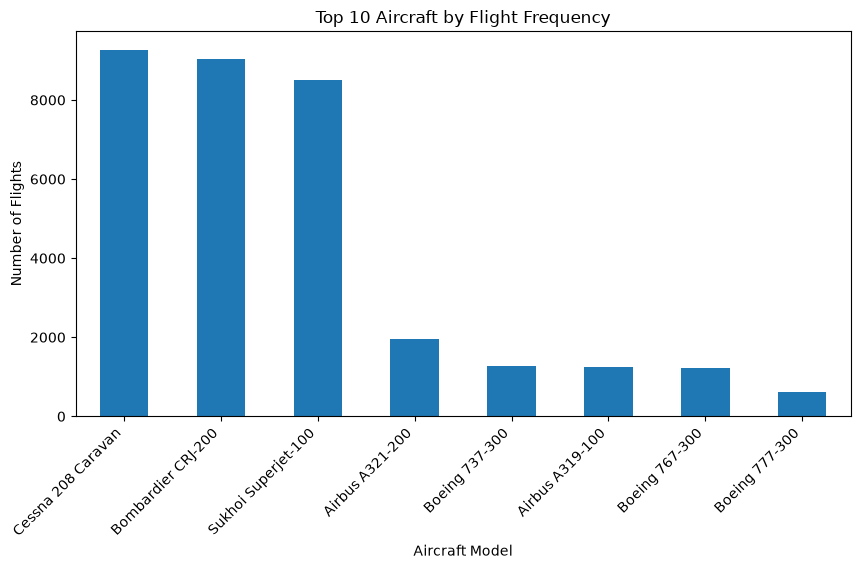

In [137]:


plt.figure(figsize=(10,5))
aircraft_frequency.head(10).plot(kind='bar')

plt.xlabel("Aircraft Model")
plt.ylabel("Number of Flights")
plt.title("Top 10 Aircraft by Flight Frequency")
plt.xticks(rotation=45, ha='right')
plt.show()

## Aircraft capacity analysis

In [145]:

aircraft_capacity = seats.groupby('aircraft_code').size()
aircraft_capacity.sort_values(ascending=False).head(10)

aircraft_code
773    402
763    222
321    170
320    140
733    130
319    116
SU9     97
CR2     50
CN1     12
dtype: int64

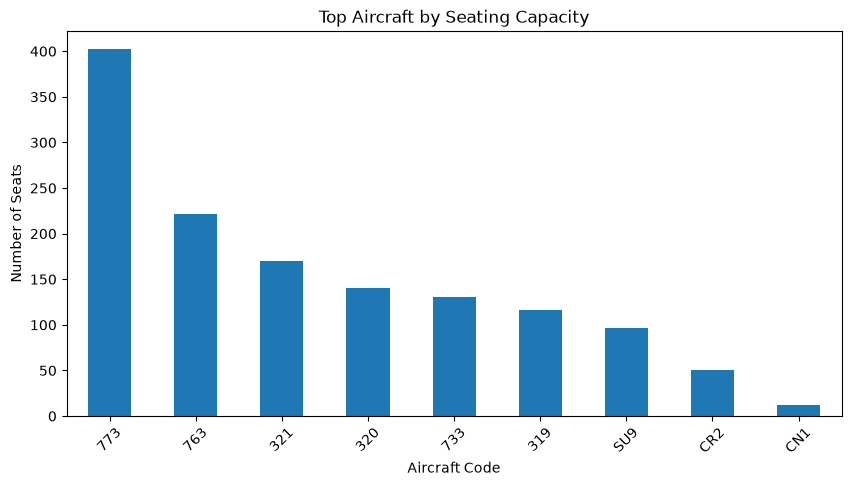

In [146]:
plt.figure(figsize=(10,5))
aircraft_capacity.sort_values(ascending=False).head(10).plot(kind='bar')

plt.xlabel("Aircraft Code")
plt.ylabel("Number of Seats")
plt.title("Top Aircraft by Seating Capacity")
plt.xticks(rotation=45)
plt.show()

## Fare Distribution

In [147]:
ticket_flights['amount'].describe()

count    1.045726e+06
mean     1.985891e+04
std      2.261239e+04
min      3.000000e+03
25%      7.200000e+03
50%      1.340000e+04
75%      2.310000e+04
max      2.033000e+05
Name: amount, dtype: float64

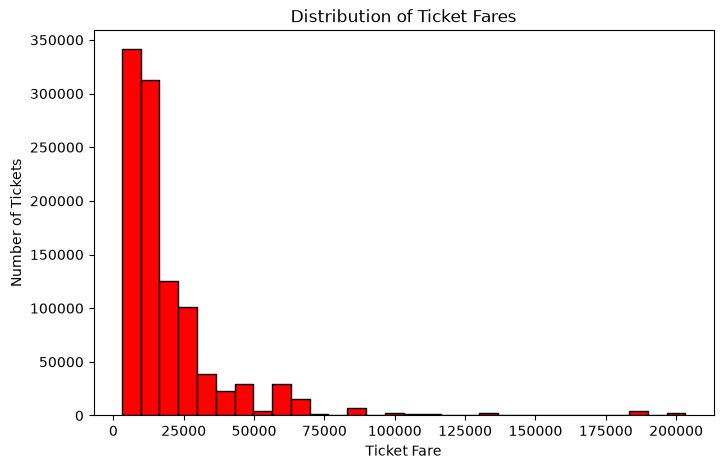

In [149]:
plt.figure(figsize=(8,5))

plt.hist(
    ticket_flights['amount'].dropna(),
    bins=30,
    color='red',
    edgecolor='black'
)

plt.xlabel("Ticket Fare")
plt.ylabel("Number of Tickets")
plt.title("Distribution of Ticket Fares")

plt.show()

## Average fare by fare condition

In [150]:
fare_condition = ticket_flights.groupby('fare_conditions')['amount'].mean()

fare_condition

fare_conditions
Business    51143.416139
Comfort     32740.552889
Economy     15959.813335
Name: amount, dtype: float64

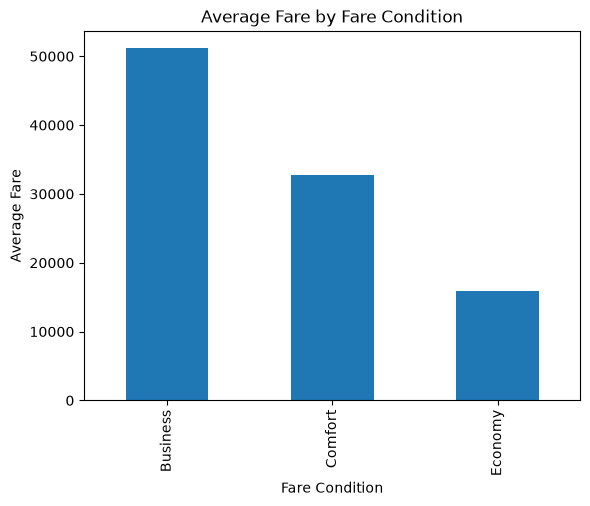

In [151]:
fare_condition.plot(kind='bar')

plt.xlabel("Fare Condition")
plt.ylabel("Average Fare")
plt.title("Average Fare by Fare Condition")
plt.show()

## Revenue by flight

In [152]:
flight_revenue = (
    ticket_flights.groupby('flight_id')['amount']
    .sum()
    .sort_values(ascending=False)
)

flight_revenue.head(10)

flight_id
2354     17146600
26212    17023600
2364     16962100
2330     16900600
2329     16894400
2341     16839100
2369     16777600
2344     16777600
26162    16593100
2332     16593100
Name: amount, dtype: int64

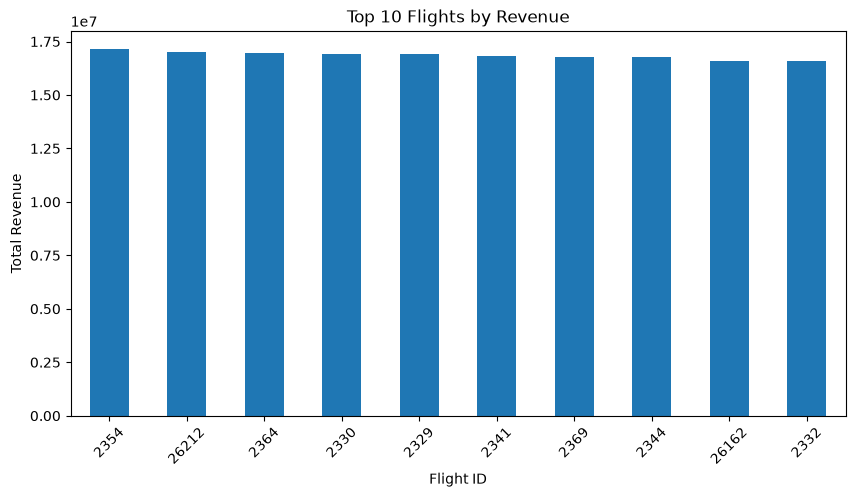

In [157]:
plt.figure(figsize=(10,5))

flight_revenue.head(10).plot(kind='bar')

plt.xlabel("Flight ID")
plt.ylabel("Total Revenue")
plt.title("Top 10 Flights by Revenue")
plt.xticks(rotation=45)

plt.show()

Inference: This identifies flights generating the highest total ticket revenue.

## Passenger count by flight

In [160]:
passengers = boarding['flight_id'].value_counts()

passengers.head(10)

flight_id
9819    374
305     365
249     365
250     361
301     357
282     355
268     355
276     355
5307    349
259     346
Name: count, dtype: int64

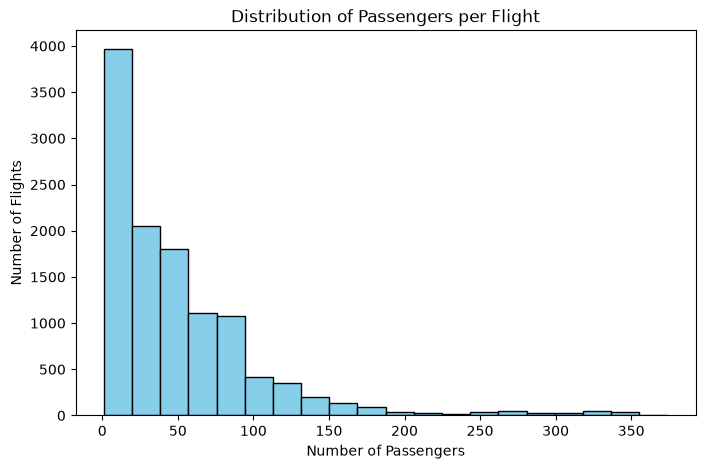

In [161]:
plt.figure(figsize=(8,5))

plt.hist(passengers, bins=20,color='skyblue', edgecolor='black')

plt.xlabel("Number of Passengers")
plt.ylabel("Number of Flights")
plt.title("Distribution of Passengers per Flight")

plt.show()

## Flight Occupancy

In [163]:
flight_data

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,...,average_fare,departure_city,arrival_city,empty_seats,occupancy_rate,revenue_per_available_seat,route,month,day_name,departure_hour
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,...,38300.000000,Moscow,Bratsk,NaN,NaN,660.344828,DME -> BTK,9,Sunday,9
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,...,19514.285714,Moscow,Khanty-Mansiysk,NaN,NaN,10928.000000,VKO -> HMA,8,Friday,14
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,...,18960.975610,Moscow,Sochi,NaN,NaN,3501.801802,VKO -> AER,9,Tuesday,12
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,...,14533.333333,Moscow,Ufa,NaN,NaN,589.189189,SVO -> UFA,9,Tuesday,9
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,...,10006.666667,Moscow,Ulyanovsk,NaN,NaN,1547.422680,SVO -> ULV,9,Monday,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,...,5462.500000,Saransk,Moscow,34.0,32.0,1748.000000,SKX -> SVO,8,Wednesday,19
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00,...,5431.250000,Saransk,Moscow,34.0,32.0,1738.000000,SKX -> SVO,7,Friday,19
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT,...,5400.000000,Saransk,Moscow,NaN,NaN,432.000000,SKX -> SVO,9,Friday,19
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00,...,5400.000000,Saransk,Moscow,37.0,26.0,1404.000000,SKX -> SVO,8,Tuesday,19


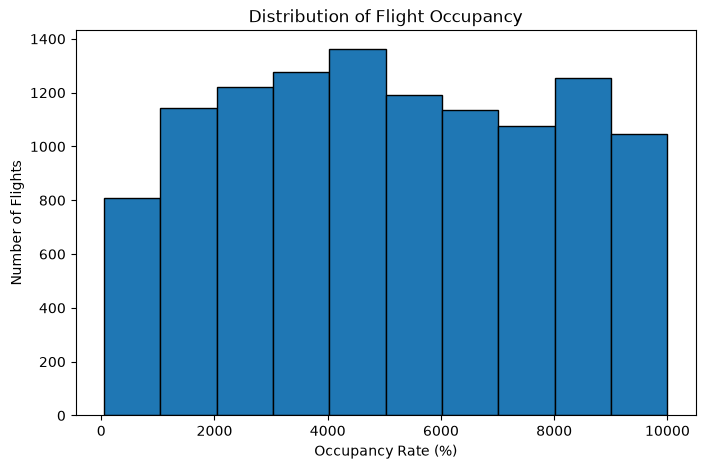

In [162]:
plt.figure(figsize=(8,5))

plt.hist(
    flight_data['occupancy_rate'].dropna() * 100,
    bins=10,
    edgecolor='black'
)

plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Flight Occupancy")

plt.show()

In [164]:
flight_data.columns

Index(['flight_id', 'flight_no', 'scheduled_departure', 'scheduled_arrival',
       'departure_airport', 'arrival_airport', 'status', 'aircraft_code',
       'actual_departure', 'actual_arrival', 'model', 'range', 'total_seats',
       'boarded_passengers', 'ticket_revenue', 'average_fare',
       'departure_city', 'arrival_city', 'empty_seats', 'occupancy_rate',
       'revenue_per_available_seat', 'route', 'month', 'day_name',
       'departure_hour'],
      dtype='str')

Inference: This shows how efficiently available seats are being utilized across flights.

## Average Occupancy by Aircraft

In [166]:
aircraft_occupancy = (
    flight_data.groupby('model')['occupancy_rate']
    .mean()
    .sort_values(ascending=False)
)

aircraft_occupancy.round(2)

model
Boeing 777-300         65.90
Boeing 737-300         61.73
Sukhoi Superjet-100    58.57
Airbus A321-200        52.24
Boeing 767-300         51.32
Cessna 208 Caravan     50.04
Airbus A319-100        46.19
Bombardier CRJ-200     42.97
Name: occupancy_rate, dtype: float64

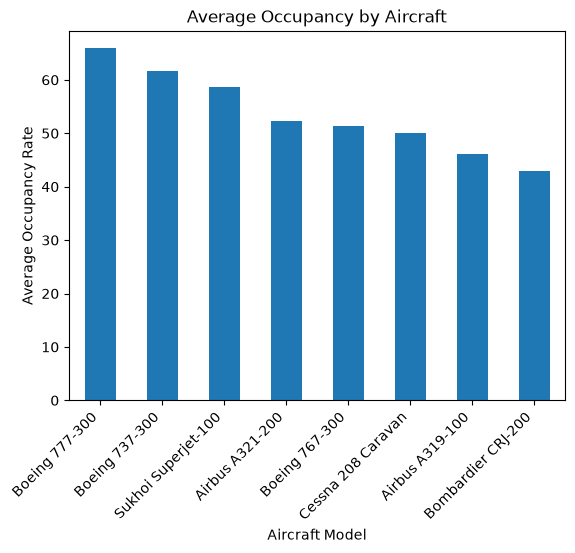

In [167]:
aircraft_occupancy.head(10).plot(kind='bar')

plt.xlabel("Aircraft Model")
plt.ylabel("Average Occupancy Rate")
plt.title("Average Occupancy by Aircraft")
plt.xticks(rotation=45, ha='right')
plt.show()

Inference: This compares how effectively different aircraft models utilize their available seating capacity.

## Revenue by Aircraft

In [168]:
revenue_aircraft = (
    flight_data.groupby('model')['ticket_revenue']
    .sum()
    .sort_values(ascending=False)
)

revenue_aircraft.head(10)

model
Sukhoi Superjet-100    5.114485e+09
Boeing 767-300         4.371277e+09
Boeing 777-300         3.431206e+09
Airbus A319-100        2.706163e+09
Bombardier CRJ-200     1.982760e+09
Airbus A321-200        1.638164e+09
Boeing 737-300         1.426552e+09
Cessna 208 Caravan     9.637380e+07
Name: ticket_revenue, dtype: float64

Inference: This identifies aircraft models associated with the highest total ticket revenue.

## Revenue by Route

In [169]:
flight_data['route'] = (
    flight_data['departure_airport'] +
    " -> " +
    flight_data['arrival_airport']
)

In [170]:
route_revenue = (
    flight_data.groupby('route')['ticket_revenue']
    .sum()
    .sort_values(ascending=False)
)

route_revenue.head(10)

route
DME -> KHV    753478300.0
KHV -> DME    733797800.0
DME -> OVB    548218900.0
OVB -> DME    531503700.0
KHV -> LED    507672400.0
LED -> KHV    498750700.0
SVO -> OVB    458130400.0
OVB -> SVO    446051200.0
LED -> IKT    411603000.0
IKT -> LED    404050300.0
Name: ticket_revenue, dtype: float64

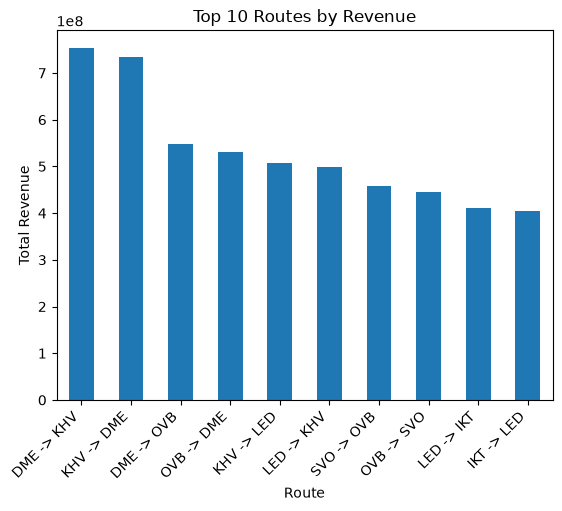

In [171]:
route_revenue.head(10).plot(kind='bar')

plt.xlabel("Route")
plt.ylabel("Total Revenue")
plt.title("Top 10 Routes by Revenue")
plt.xticks(rotation=45, ha='right')
plt.show()

Inference: This identifies the routes generating the highest ticket revenue.

## Most Popular routes

In [172]:
popular_routes = flight_data['route'].value_counts()

popular_routes.head(10)

route
SVO -> LED    305
LED -> SVO    305
DME -> LED    244
LED -> DME    244
DME -> BZK    183
VKO -> LED    183
VKO -> BZK    183
SVO -> BZK    183
LED -> VKO    183
BZK -> DME    183
Name: count, dtype: int64

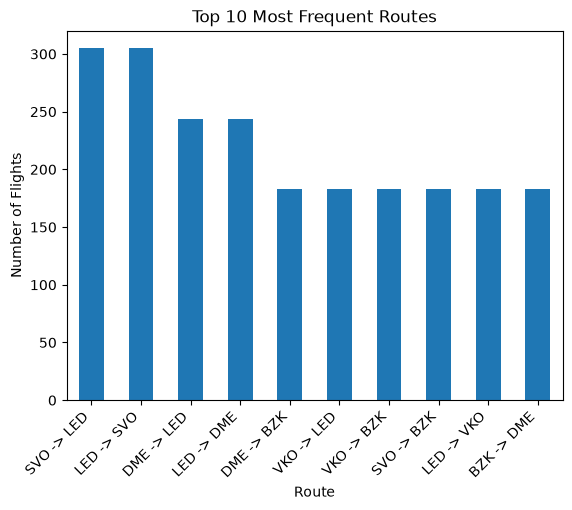

In [173]:
popular_routes.head(10).plot(kind='bar')

plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.title("Top 10 Most Frequent Routes")
plt.xticks(rotation=45, ha='right')
plt.show()

## Deparature hour analysis

In [174]:
flight_data['departure_hour'] = (
    flight_data['scheduled_departure'].dt.hour
)

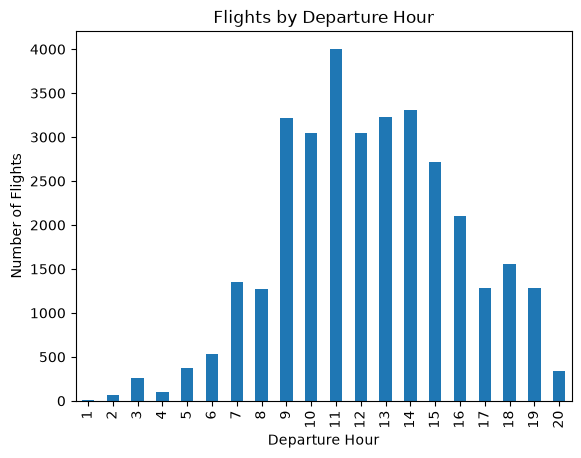

In [177]:
hourly_flights = flight_data['departure_hour'].value_counts().sort_index()

hourly_flights.plot(kind='bar')

plt.xlabel("Departure Hour")
plt.ylabel("Number of Flights")
plt.title("Flights by Departure Hour")
plt.show()

Inference: This shows the hours of the day when flight activity is highest.

## Monthly flight analysis

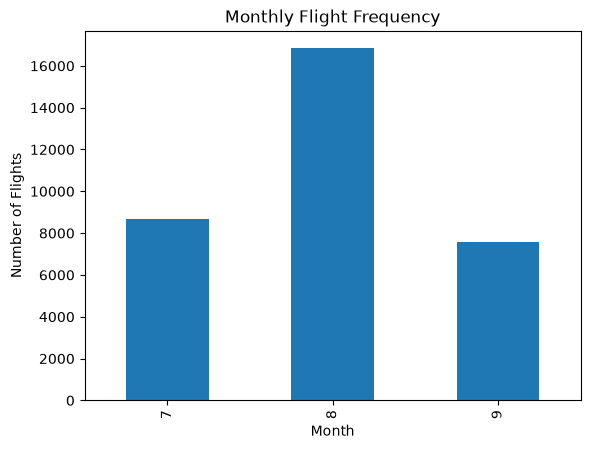

In [178]:
monthly_flights = (
    flight_data['month']
    .value_counts()
    .sort_index()
)

monthly_flights.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.title("Monthly Flight Frequency")
plt.show()

## Average fare by route

In [179]:
route_fare = (
    flight_data.groupby('route')['average_fare']
    .mean()
    .sort_values(ascending=False)
)

route_fare.head(10)

route
MRV -> GDX    91360.078463
SVO -> UUS    89810.913345
GDX -> MRV    89794.691707
DME -> PKC    88501.772851
UUS -> SVO    88203.534247
DME -> UUS    88203.297406
UUS -> DME    87778.406188
PKC -> DME    87722.369708
VKO -> VVO    82691.565003
SVO -> DYR    82210.934446
Name: average_fare, dtype: float64

Inference: This identifies routes with comparatively higher average ticket fares.

## Occupancy vs Revenue

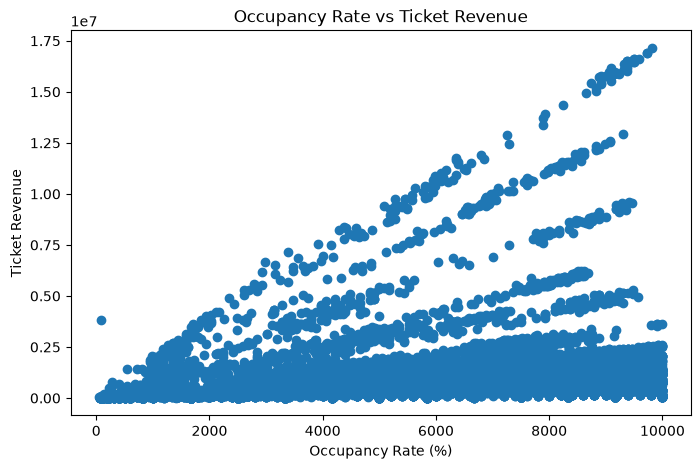

In [180]:
plt.figure(figsize=(8,5))

plt.scatter(
    flight_data['occupancy_rate'] * 100,
    flight_data['ticket_revenue']
)

plt.xlabel("Occupancy Rate (%)")
plt.ylabel("Ticket Revenue")
plt.title("Occupancy Rate vs Ticket Revenue")

plt.show()

Inference: This helps examine whether flights with higher seat occupancy tend to generate higher ticket revenue.

## Correlation analysis

In [181]:
flight_data[
    ['total_seats',
     'boarded_passengers',
     'occupancy_rate',
     'ticket_revenue',
     'average_fare']
].corr()

,total_seats,boarded_passengers,occupancy_rate,ticket_revenue,average_fare
total_seats,1.000000,0.834999,0.141721,0.622318,0.323851
boarded_passengers,0.834999,1.000000,0.558238,0.709241,0.156779
occupancy_rate,0.141721,0.558238,1.000000,0.282840,-0.103754
ticket_revenue,0.622318,0.709241,0.282840,1.000000,0.605970
average_fare,0.323851,0.156779,-0.103754,0.605970,1.000000


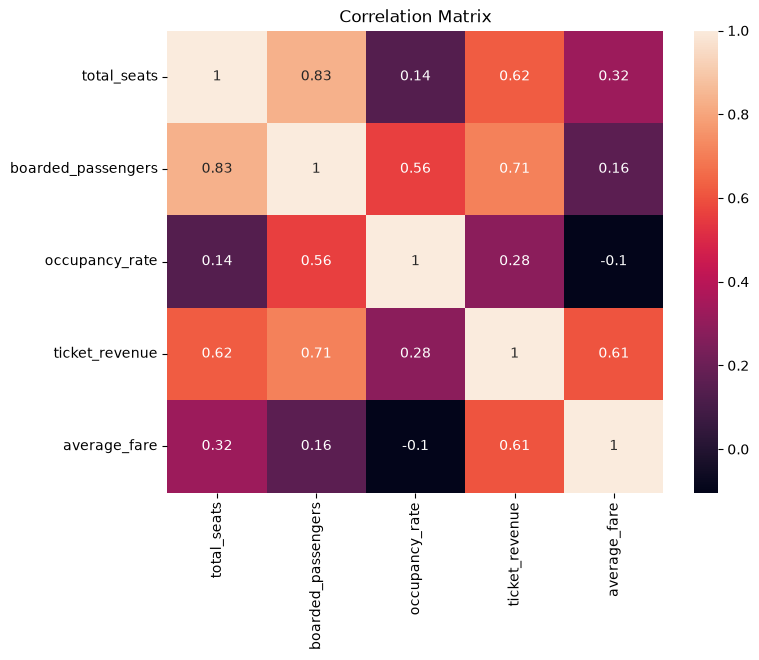

In [182]:
plt.figure(figsize=(8,6))

sns.heatmap(
    flight_data[
        ['total_seats',
         'boarded_passengers',
         'occupancy_rate',
         'ticket_revenue',
         'average_fare']
    ].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

This helps you understand relationships between capacity, passengers, occupancy, fare, and revenue.